`Notebook last edit: 2022/23`

# Recommender Systems 2026/27

### Practice 1 - Non personalized recommenders

### We will use the Movielens 10 million dataset. We download it and uncompress the file we need.

### In order to reuse it in the future, we will put all of that in a class that we can call easily

In [1]:
from urllib.request import urlretrieve
import zipfile, os

In [2]:
# If file exists, skip the download
data_file_path = "Data_manager_split_datasets/Movielens10M/"
data_file_name = data_file_path + "movielens_10m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("http://files.grouplens.org/datasets/movielens/ml-10m.zip", data_file_name)

In [3]:
dataFile = zipfile.ZipFile(data_file_path + "movielens_10m.zip")

URM_path = dataFile.extract("ml-10M100K/ratings.dat", path = data_file_path + "decompressed/")

URM_file = open(URM_path, 'r')

In [4]:
type(URM_file)

_io.TextIOWrapper

#### Let's take a look at the data

In [5]:
import pandas as pd

In [6]:
URM_all_dataframe = pd.read_csv(filepath_or_buffer=URM_path, 
                                sep="::", 
                                header=None, 
                                dtype={0:int, 1:int, 2:float, 3:int},
                                engine='python')

URM_all_dataframe.columns = ["UserID", "ItemID", "Interaction", "Timestamp"]

In [7]:
URM_all_dataframe.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,1,122,5.0,838985046
1,1,185,5.0,838983525
2,1,231,5.0,838983392
3,1,292,5.0,838983421
4,1,316,5.0,838983392
5,1,329,5.0,838983392
6,1,355,5.0,838984474
7,1,356,5.0,838983653
8,1,362,5.0,838984885
9,1,364,5.0,838983707


In [8]:
print ("The number of interactions is {}".format(len(URM_all_dataframe)))

The number of interactions is 10000054


### We can use this data to create a sparse matrix, notice that we have red UserID and ItemID as int
### This is not always possible if the IDs are alphanumeric

### Now we can extract the list of unique user id and item id and display some statistics

In [9]:
userID_unique = URM_all_dataframe["UserID"].unique()
itemID_unique = URM_all_dataframe["ItemID"].unique()

In [10]:
n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(URM_all_dataframe)

print ("Number of items\t {}, Number of users\t {}".format(n_items, n_users))
print ("Max ID items\t {}, Max Id users\t {}\n".format(max(itemID_unique), max(userID_unique)))

Number of items	 10677, Number of users	 69878
Max ID items	 65133, Max Id users	 71567



### See that the max ID of items and users is higher than the number of unique values -> empty profiles
### We should remove empty indices, to do so we create a new mapping

In [11]:
mapped_id, original_id = pd.factorize(URM_all_dataframe["UserID"].unique())
user_original_ID_to_index = pd.Series(mapped_id, index=original_id)

mapped_id, original_id = pd.factorize(URM_all_dataframe["ItemID"].unique())
item_original_ID_to_index = pd.Series(mapped_id, index=original_id)

In [12]:
original_item_ID = 292
print("New index for item {} is {}".format(original_item_ID, item_original_ID_to_index[original_item_ID]))

New index for item 292 is 3


### We now replace the IDs in the dataframe and we are ready to use the data

In [13]:
URM_all_dataframe["UserID"] = URM_all_dataframe["UserID"].map(user_original_ID_to_index)
URM_all_dataframe["ItemID"] = URM_all_dataframe["ItemID"].map(item_original_ID_to_index)

In [14]:
URM_all_dataframe.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,0,0,5.0,838985046
1,0,1,5.0,838983525
2,0,2,5.0,838983392
3,0,3,5.0,838983421
4,0,4,5.0,838983392
5,0,5,5.0,838983392
6,0,6,5.0,838984474
7,0,7,5.0,838983653
8,0,8,5.0,838984885
9,0,9,5.0,838983707


In [15]:
userID_unique = URM_all_dataframe["UserID"].unique()
itemID_unique = URM_all_dataframe["ItemID"].unique()

n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(URM_all_dataframe)

print ("Number of items\t {}, Number of users\t {}".format(n_items, n_users))
print ("Max ID items\t {}, Max Id users\t {}\n".format(max(itemID_unique), max(userID_unique)))
print ("Average interactions per user {:.2f}".format(n_interactions/n_users))
print ("Average interactions per item {:.2f}\n".format(n_interactions/n_items))

print ("Sparsity {:.2f} %".format((1-float(n_interactions)/(n_items*n_users))*100))


Number of items	 10677, Number of users	 69878
Max ID items	 10676, Max Id users	 69877

Average interactions per user 143.11
Average interactions per item 936.60

Sparsity 98.66 %


##### Rating distribution in time

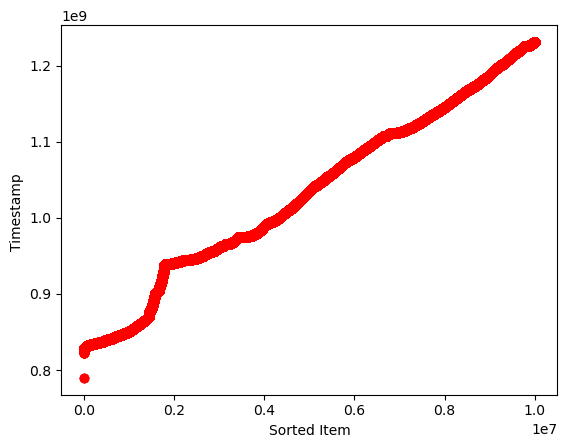

In [16]:
import matplotlib.pyplot as pyplot

# Clone the list to avoid changing the ordering of the original data
timestamp_sorted = URM_all_dataframe["Timestamp"].values.copy()
timestamp_sorted.sort()


pyplot.plot(timestamp_sorted, 'ro')
pyplot.ylabel('Timestamp ')
pyplot.xlabel('Sorted Item')
pyplot.show()

#### To store the data we use a sparse matrix. We build it as a COO matrix and then change its format

#### The COO constructor expects (data, (row, column))

In [17]:
import scipy.sparse as sps

URM_all = sps.coo_matrix((URM_all_dataframe["Interaction"].values, 
                          (URM_all_dataframe["UserID"].values, URM_all_dataframe["ItemID"].values)))

URM_all

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 10000054 stored elements in COOrdinate format>

In [18]:
URM_all.tocsr()

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 10000054 stored elements in Compressed Sparse Row format>

### We compute the item popularity as the number of interaction in each column

### We can use the properties of sparse matrices in CSC format

In [19]:
import numpy as np

item_popularity = np.ediff1d(URM_all.tocsc().indptr)
item_popularity

array([ 2412, 14975, 17851, ...,     1,     1,     1], dtype=int32)

In [20]:
item_popularity = np.sort(item_popularity)
item_popularity

array([    1,     1,     1, ..., 33668, 34457, 34864], dtype=int32)

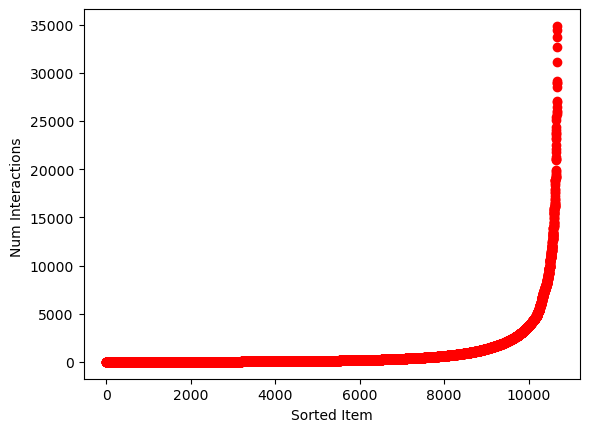

In [21]:
pyplot.plot(item_popularity, 'ro')
pyplot.ylabel('Num Interactions ')
pyplot.xlabel('Sorted Item')
pyplot.show()

In [22]:
ten_percent = int(n_items/10)

print("Average per-item interactions over the whole dataset {:.2f}".
      format(item_popularity.mean()))

print("Average per-item interactions for the top 10% popular items {:.2f}".
      format(item_popularity[-ten_percent:].mean()))

print("Average per-item interactions for the least 10% popular items {:.2f}".
      format(item_popularity[:ten_percent].mean()))

print("Average per-item interactions for the median 10% popular items {:.2f}".
      format(item_popularity[int(n_items*0.45):int(n_items*0.55)].mean()))

Average per-item interactions over the whole dataset 936.60
Average per-item interactions for the top 10% popular items 6479.52
Average per-item interactions for the least 10% popular items 5.23
Average per-item interactions for the median 10% popular items 136.45


In [23]:
print("Number of items with zero interactions {}".
      format(np.sum(item_popularity==0)))

Number of items with zero interactions 0


### We compute the user activity (profile length) as the number of interaction in each row

### We can use the properties of sparse matrices in CSR format

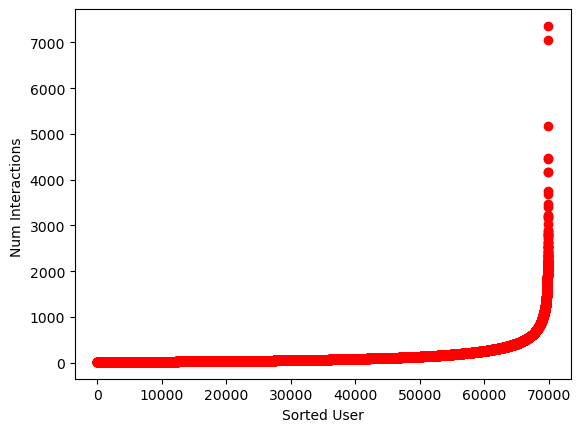

In [24]:
user_activity = np.ediff1d(URM_all.tocsr().indptr)
user_activity = np.sort(user_activity)


pyplot.plot(user_activity, 'ro')
pyplot.ylabel('Num Interactions ')
pyplot.xlabel('Sorted User')
pyplot.show()

### In order to evaluate our recommender we have to define:
* A splitting of the data in URM_train and URM_test
* An evaluation metric
* A functon computing the evaluation for each user

### The splitting of the data is very important to ensure your algorithm is evaluated in a realistic scenario by using test it has never seen. We create two splits:
#### - Train data: we will use this to train our model
#### - Test data: we will use this to evaluate our model

In [25]:
train_test_split = 0.80

n_interactions = URM_all.nnz


train_mask = np.random.choice([True,False], n_interactions, p=[train_test_split, 1-train_test_split])
train_mask

array([ True,  True,  True, ...,  True,  True,  True])

In [26]:
URM_train = sps.csr_matrix((URM_all.data[train_mask],
                            (URM_all.row[train_mask], URM_all.col[train_mask])))

URM_train

<69878x10676 sparse matrix of type '<class 'numpy.float64'>'
	with 8001248 stored elements in Compressed Sparse Row format>

In [27]:
test_mask = np.logical_not(train_mask)

URM_test = sps.csr_matrix((URM_all.data[test_mask],
                            (URM_all.row[test_mask], URM_all.col[test_mask])))

URM_test

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 1998806 stored elements in Compressed Sparse Row format>

### Evaluation metrics

#### We call items in the test set 'relevant'

In [28]:
user_id = 124
relevant_items = URM_test[user_id].indices
relevant_items

array([  11,   74,   79,   93,  144,  145,  179,  231,  235,  238,  312,
        398,  415,  423, 1303, 1310, 1321, 1427, 1429, 1458, 1466, 1468,
       1496, 2310], dtype=int32)

#### Say that we have a recommendation list such as this

In [29]:
recommended_items = np.array([241, 1622, 15, 857, 5823])
recommended_items

array([ 241, 1622,   15,  857, 5823])

In [30]:
is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)
is_relevant

array([False, False, False, False, False])

### Precision: how many of the recommended items are relevant

In [31]:
def precision(recommended_items, relevant_items):
    
    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)
    
    precision_score = np.sum(is_relevant, dtype=np.float32) / len(is_relevant)
    
    return precision_score

### Recall: how many of the relevant items I was able to recommend

In [32]:
def recall(recommended_items, relevant_items):
    
    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)
    
    recall_score = np.sum(is_relevant, dtype=np.float32) / relevant_items.shape[0]
    
    return recall_score

### Average Precision

In [33]:
def AP(recommended_items, relevant_items):
   
    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)
    
    # Cumulative sum: precision at 1, at 2, at 3 ...
    p_at_k = is_relevant * np.cumsum(is_relevant, dtype=np.float32) / (1 + np.arange(is_relevant.shape[0]))
    
    ap_score = np.sum(p_at_k) / np.min([relevant_items.shape[0], is_relevant.shape[0]])

    return ap_score

def plot_pr_curve(recommended_items, relevant_items):
    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)

    # Cumulative sum: precision at 1, at 2, at 3 ...
    p_at_k = is_relevant * np.cumsum(
        is_relevant, dtype=np.float32
    ) / (1 + np.arange(is_relevant.shape[0]))

    r_at_k = np.cumsum(
        is_relevant, dtype=np.float32
    ) / relevant_items.shape[0]

    pyplot.plot(r_at_k[is_relevant], p_at_k[is_relevant], "ro", linestyle="--")
    pyplot.xlabel("Recall")
    pyplot.ylabel("Precision")
    pyplot.title("Precision-Recall Curve")
    pyplot.xlim(0, 1)
    pyplot.ylim(0, 1)

In [34]:
def ndcg(recommended_items, relevant_items):
    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)

    discounts = np.log2(1 + np.arange(1, is_relevant.shape[0] + 1))
    dcg_at_k = np.sum(is_relevant / discounts)

    ideal_is_relevant = np.ones(
        np.min([relevant_items.shape[0], recommended_items.shape[0]]), dtype=np.float32
    )
    ideal_discounts = np.log2(
        1 + np.arange(1, ideal_is_relevant.shape[0] + 1)
    )
    idcg_at_k = np.sum(ideal_is_relevant / ideal_discounts)

    if idcg_at_k <= 0:
        ndcg_score = 0.0
    else:
        ndcg_score = dcg_at_k / idcg_at_k

    return ndcg_score

### Now that we have the data, we can build our first recommender. We need two things:
* a 'fit' function to train our model
* a 'recommend' function that uses our model to recommend

### Let's start with a random recommender

#### In a random recommend we don't have anything to learn from the data

In [35]:
class RandomRecommender(object):

    def fit(self, URM_train):
           
        self.n_items = URM_train.shape[1]
    
    
    def recommend(self, user_id, at=5):
    
        recommended_items = np.random.choice(self.n_items, at)

        return recommended_items

In [36]:
randomRecommender = RandomRecommender()
randomRecommender.fit(URM_train)

for user_id in range(10):
    print(randomRecommender.recommend(user_id, at=5))

[7223 1382 6673 4052  911]
[5265 3226  322 4161 1542]
[ 3090  1992 10322   424  2224]
[3299 8048 5328 7282 5054]
[5200 9853 6424 8722 7394]
[5590 4260 1326  226 7852]
[ 3971  2425  4815 10280  1611]
[7016 5204 9297 1335 9933]
[ 563 7445  258 5618 7927]
[8678 1866 4810 2438 8777]


### Put all together in an evaluation function and let's test it!

In [37]:
# We pass as paramether the recommender class

def evaluate_algorithm(URM_test, recommender_object, at=5):
    
    cumulative_precision = 0.0
    cumulative_recall = 0.0
    cumulative_AP = 0.0
    cumulative_ndcg = 0.0
    
    num_eval = 0


    for user_id in range(URM_test.shape[0]):

        relevant_items = URM_test.indices[URM_test.indptr[user_id]:URM_test.indptr[user_id+1]]
        
        if len(relevant_items)>0:
            
            recommended_items = recommender_object.recommend(user_id, at=at)
            num_eval+=1

            cumulative_precision += precision(recommended_items, relevant_items)
            cumulative_recall += recall(recommended_items, relevant_items)
            cumulative_AP += AP(recommended_items, relevant_items)
            cumulative_ndcg += ndcg(recommended_items, relevant_items)
            
    cumulative_precision /= num_eval
    cumulative_recall /= num_eval
    MAP = cumulative_AP / num_eval
    cumulative_ndcg /= num_eval
    
    print("Recommender results are: Precision = {:.4f}, Recall = {:.4f}, MAP = {:.4f}, NDCG = {:.4f}".format(
        cumulative_precision, cumulative_recall, MAP, cumulative_ndcg)) 

In [38]:
evaluate_algorithm(URM_test, randomRecommender)

Recommender results are: Precision = 0.0030, Recall = 0.0005, MAP = 0.0014, NDCG = 0.0031


Let's analyze the Precision-Recall curve profile for one sampled user. What will it look like for a Random Recommender?

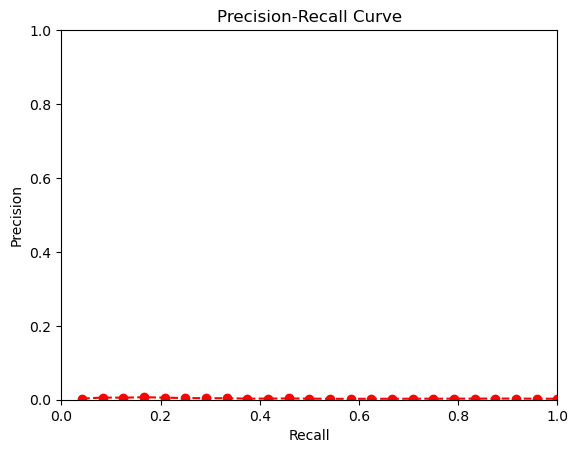

In [39]:
user_id = 124
recommended_items = randomRecommender.recommend(user_id, at=URM_all.shape[1])
relevant_items = URM_test.indices[URM_test.indptr[user_id]:URM_test.indptr[user_id + 1]]

plot_pr_curve(recommended_items, relevant_items)

### So the code works. The recommendation quality however...

# Top Popular recommender

#### We recommend to all users the most popular items, that is those with the highest number of interactions
#### In this case our model is the item popularity

In [40]:
class TopPopRecommender(object):

    def fit(self, URM_train):

        item_popularity = np.ediff1d(URM_train.tocsc().indptr)

        # We are not interested in sorting the popularity value,
        # but to order the items according to it
        self.popular_items = np.argsort(item_popularity)
        self.popular_items = np.flip(self.popular_items, axis = 0)
    
    
    def recommend(self, user_id, at=5):
    
        recommended_items = self.popular_items[0:at]

        return recommended_items



### Now train and test our model

In [41]:
topPopRecommender = TopPopRecommender()
topPopRecommender.fit(URM_train)

In [42]:
for user_id in range(10):
    print(topPopRecommender.recommend(user_id, at=5))

[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]


In [43]:
evaluate_algorithm(URM_test, topPopRecommender, at=5)

Recommender results are: Precision = 0.0955, Recall = 0.0308, MAP = 0.0527, NDCG = 0.0978


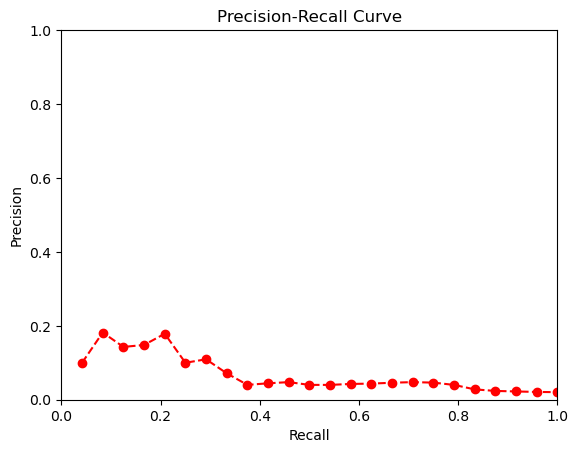

In [44]:
user_id = 124
recommended_items = topPopRecommender.recommend(user_id, at=URM_all.shape[1])
relevant_items = URM_test.indices[URM_test.indptr[user_id]:URM_test.indptr[user_id + 1]]

plot_pr_curve(recommended_items, relevant_items)

### That's better, but we can improve

### Hint, remove items already seen by the user. We can either remove them from the recommended item list or we can set them to a score so low that it will cause them to end at the very bottom of all the available items

In [45]:
class TopPopRecommender(object):

    def fit(self, URM_train):
        
        self.URM_train = URM_train

        item_popularity = np.ediff1d(URM_train.tocsc().indptr)

        # We are not interested in sorting the popularity value,
        # but to order the items according to it
        self.popular_items = np.argsort(item_popularity)
        self.popular_items = np.flip(self.popular_items, axis = 0)
    
    
    def recommend(self, user_id, at=5, remove_seen=True):

        if remove_seen:
            seen_items = self.URM_train.indices[self.URM_train.indptr[user_id]:self.URM_train.indptr[user_id+1]]
            
            unseen_items_mask = np.in1d(self.popular_items, seen_items, assume_unique=True, invert = True)

            unseen_items = self.popular_items[unseen_items_mask]

            recommended_items = unseen_items[0:at]

        else:
            recommended_items = self.popular_items[0:at]
            

        return recommended_items


In [46]:
topPopRecommender_removeSeen = TopPopRecommender()
topPopRecommender_removeSeen.fit(URM_train)

for user_id in range(10):
    print(topPopRecommender_removeSeen.recommend(user_id, at=5))

[1008  139 1293   22  175]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7   14 1293   22]
[1008    7 1293   22  175]
[1008    7  139   14 1293]
[   7   14 1293   22   19]


In [47]:
evaluate_algorithm(URM_test, topPopRecommender_removeSeen)

Recommender results are: Precision = 0.1983, Recall = 0.0534, MAP = 0.1472, NDCG = 0.2132


#### Simple but effective. Always remove seen items if your purpose is to recommend "new" ones

# Global effects recommender

#### We recommend to all users the highest rated items

#### First we compute the average of all ratings, or global average

In [48]:
globalAverage = np.mean(URM_train.data)

print("The global average is {:.2f}".format(globalAverage))

The global average is 3.51


#### We subtract the bias to all ratings

In [49]:
URM_train_unbiased = URM_train.copy()

URM_train_unbiased.data -= globalAverage

print(URM_train_unbiased.data[0:10])

[1.48754551 1.48754551 1.48754551 1.48754551 1.48754551 1.48754551
 1.48754551 1.48754551 1.48754551 1.48754551]


#### Then we compute the average rating for each item, or itemBias

We cannot use the mean function because it would include also the zero values, which we want to exclude since they mean "missing data"

The mean should be computed only on existing ratings. To avoid attributing high rating values to items rated by only a few users we can add a constant term to the denominator in order to penalize items with very few ratings.

In [50]:
lambda_item = 25
lambda_user = 10

In [51]:
# This computes the mean of the column excluding the missing values
col_nnz = np.ediff1d(sps.csc_matrix(URM_train_unbiased).indptr)

item_mean_rating = URM_train_unbiased.sum(axis=0) / (col_nnz + lambda_item)
item_mean_rating = np.asarray(item_mean_rating).ravel()  # converts 2-d matrix to 1-d array without anycopy
item_mean_rating[col_nnz==0] = -np.inf

item_mean_rating

array([-0.63877528, -0.38631671, -0.56985173, ...,        -inf,
       -0.05817133,  0.01875175])

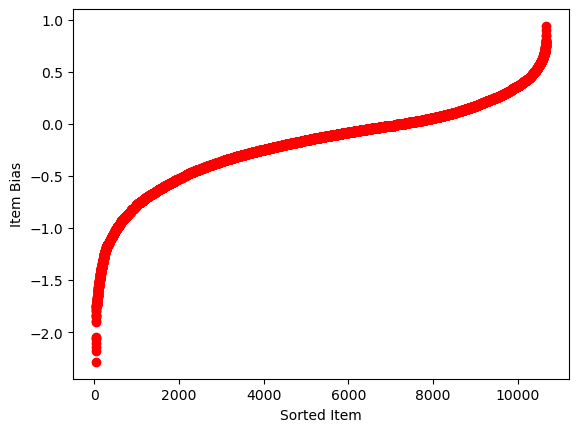

In [52]:
item_mean_rating = np.array(item_mean_rating).squeeze()
item_mean_rating = np.sort(item_mean_rating[item_mean_rating!=0])

pyplot.plot(item_mean_rating, 'ro')
pyplot.ylabel('Item Bias')
pyplot.xlabel('Sorted Item')
pyplot.show()

#### And the average rating for each user, or userBias

In [53]:
# This computes the mean of the row excluding the missing values
row_nnz = np.ediff1d(sps.csr_matrix(URM_train_unbiased).indptr)

# finally, let's compute the bias
user_mean_rating = URM_train_unbiased.sum(axis=1).ravel() / (row_nnz + lambda_user)
user_mean_rating = np.asarray(user_mean_rating).ravel()
user_mean_rating[row_nnz==0] = -np.inf
        
user_mean_rating

array([ 0.991697  , -0.1074727 ,  0.34226294, ...,  0.32595644,
        0.23059263, -0.21202388])

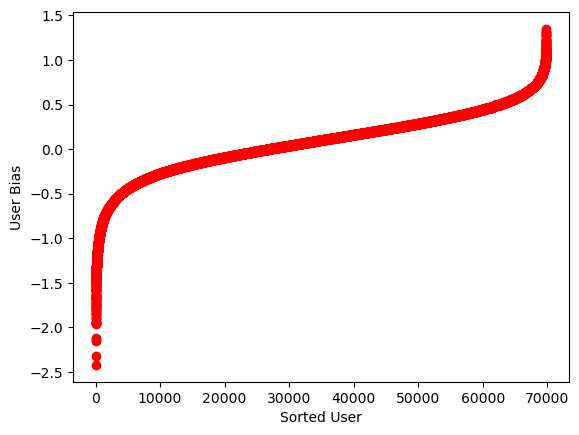

In [54]:
user_mean_rating = np.array(user_mean_rating).squeeze()
user_mean_rating = np.sort(user_mean_rating[user_mean_rating!=0.0])

pyplot.plot(user_mean_rating, 'ro')
pyplot.ylabel('User Bias')
pyplot.xlabel('Sorted User')
pyplot.show()

#### Now we can sort the items by their itemBias and use the same recommendation principle as in TopPop

In [55]:
class GlobalEffectsRecommender(object):

    def fit(self, URM_train, lambda_user=10, lambda_item=25):
        
        self.URM_train = URM_train

        # 1) global average
        self.mu = self.URM_train.data.sum(dtype=np.float32) / self.URM_train.nnz

        # 2) item average bias
        # compute the number of non-zero elements for each column
        col_nnz = np.ediff1d(sps.csc_matrix(self.URM_train).indptr)

        URM_train_unbiased = self.URM_train.copy()
        URM_train_unbiased.data -= self.mu
        
        item_bias = URM_train_unbiased.sum(axis=0) / (col_nnz + lambda_item)
        item_bias = np.asarray(item_bias).ravel()  # converts 2-d matrix to 1-d array without anycopy
        item_bias[col_nnz==0] = -np.inf 
        
        self.bestRatedItems = np.argsort(item_bias)
        self.bestRatedItems = np.flip(self.bestRatedItems, axis = 0)
        
    
    def recommend(self, user_id, at=5, remove_seen=True):

        if remove_seen:
            seen_items = self.URM_train.indices[self.URM_train.indptr[user_id]:self.URM_train.indptr[user_id+1]]
            
            unseen_items_mask = np.in1d(self.bestRatedItems, seen_items, assume_unique=True, invert = True)

            unseen_items = self.bestRatedItems[unseen_items_mask]

            recommended_items = unseen_items[0:at]

        else:
            recommended_items = self.bestRatedItems[0:at]
            

        return recommended_items



In [56]:
globalEffectsRecommender = GlobalEffectsRecommender()
globalEffectsRecommender.fit(URM_train)

evaluate_algorithm(URM_test, globalEffectsRecommender)

Recommender results are: Precision = 0.0768, Recall = 0.0197, MAP = 0.0558, NDCG = 0.0937


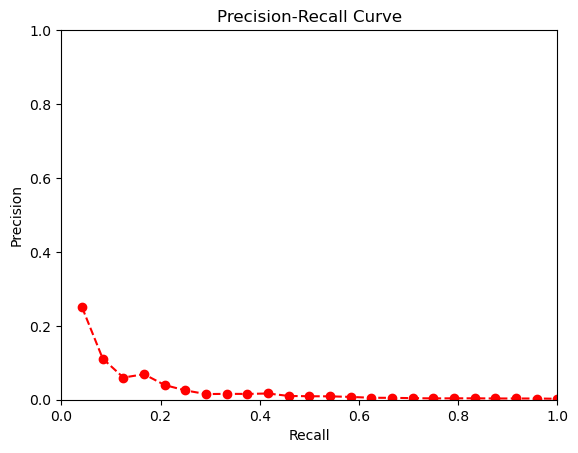

In [57]:
user_id = 124
recommended_items = globalEffectsRecommender.recommend(user_id, at=URM_all.shape[1])
relevant_items = URM_test.indices[URM_test.indptr[user_id]:URM_test.indptr[user_id + 1]]

plot_pr_curve(recommended_items, relevant_items)

#### GlobalEffects has a worse result than TopPop even though we are using "more" information.

### Let's see how TopPop accuracy changes by using only highly rated items to compute the popularity

In [58]:
for rating_threshold in range(0, 5):
    
    print("Removing ratings <= {}".format(rating_threshold))
    
    URM_train_filtered = URM_train.copy()
    URM_train_filtered.data[URM_train.data <= rating_threshold] = 0
    
    URM_train_filtered.eliminate_zeros()
    
    topPopRecommender = TopPopRecommender()
    topPopRecommender.fit(URM_train_filtered)
    
    evaluate_algorithm(URM_test, topPopRecommender)

Removing ratings <= 0
Recommender results are: Precision = 0.1983, Recall = 0.0534, MAP = 0.1472, NDCG = 0.2132
Removing ratings <= 1
Recommender results are: Precision = 0.1951, Recall = 0.0530, MAP = 0.1436, NDCG = 0.2095
Removing ratings <= 2
Recommender results are: Precision = 0.1872, Recall = 0.0511, MAP = 0.1356, NDCG = 0.2011
Removing ratings <= 3
Recommender results are: Precision = 0.1632, Recall = 0.0447, MAP = 0.1085, NDCG = 0.1718
Removing ratings <= 4
Recommender results are: Precision = 0.1223, Recall = 0.0353, MAP = 0.0739, NDCG = 0.1278


## Question:

#### Why is GlobalEffect performing worse than TopPop even if we are taking into account more information about the interaction?

#### Why TopPop getting worse if we remove interactions with low rating value?
.

.

.

.

.

.

.

.

### Sometimes ratings are not really more informative than interactions. The community has been moving away from explicit ratings for a decade now, preferring implicit interactions that are easier to collect and more reliable.

### Generally speaking, "more information" is not necessarily better if noisy or hard to model.